# Member 1 — Random Forest & Decision Tree
**COM3032/COMM074 · Airline Route Profitability · CRISP-DM: Modelling & Evaluation**

**Student:** Member 1
**Primary Model:** Random Forest Classifier
**Member 1 – Decision Tree:** Tuned with gini criterion, balanced class weights, shallow depth (max 7)
**Data:** Unscaled for both models — tree-based splits are scale-invariant

---

### Metric Justification

| Metric | Business Meaning |
|--------|------------------|
| F1-Score | Harmonic mean of Precision and Recall — balances both error types. Primary metric for imbalanced classification. |
| ROC-AUC | Measures ranking ability across all thresholds. Used for cross-member comparison. |
| MCC | Matthews Correlation Coefficient — accounts for all four confusion matrix cells. Above 0.4 indicates genuine discriminative ability. |
| TPR (Recall) | Fraction of profitable routes correctly identified. |
| TNR | Fraction of loss-making routes correctly flagged. |
| FPR | Fraction of loss-making routes wrongly approved. Drives financial cost. |
| Overfit Gap | Train F1 minus Test F1. < 0.05 = good fit; 0.05–0.10 = borderline; > 0.10 = memorising. |

## Section 1 — Imports and Setup

All libraries are imported here. Paths point to the shared `processed_data/` folder created by the group preprocessing notebook.

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)

print('Libraries loaded.')

Libraries loaded.


## Section 2 — Load Data

Both Random Forest and Decision Tree use unscaled feature splits — tree-based threshold comparisons are not affected by feature magnitude.

In [2]:
from pathlib import Path

RANDOM_STATE = 42
MEMBER       = 'member1'
# FP_COST: estimated quarterly operating cost of maintaining one unprofitable route
# FN_COST: estimated foregone revenue from incorrectly retiring a profitable route
FP_COST      = 42000
FN_COST      = 30000

MEMBER_DIR = Path.cwd()
BASE       = MEMBER_DIR.parent
PROC       = BASE / "processed_data"
FIG_DIR    = MEMBER_DIR
MEMBER_DIR.mkdir(parents=True, exist_ok=True)

print("Base folder:", BASE)
print("Member dir:", MEMBER_DIR)
print("Processed folder:", PROC)
print("Processed folder exists:", PROC.exists())

X_train = pd.read_csv(PROC / "X_train.csv")
X_val   = pd.read_csv(PROC / "X_val.csv")
X_test  = pd.read_csv(PROC / "X_test.csv")

y_train = pd.read_csv(PROC / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC / "y_test.csv").squeeze()

with open(PROC / "feature_names.json") as f:
    feature_names = json.load(f)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Base folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project
Member dir: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\Member 1
Processed folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data
Processed folder exists: True
Train: (11997, 37), Val: (1500, 37), Test: (1500, 37)
Class balance — Train: 0.637, Val: 0.637, Test: 0.637


## Section 3 — Utility Functions

All evaluation and plotting functions are defined here. `evaluate_enhanced` extends basic metrics with MCC, TNR, FPR, financial cost, and overfitting gap. `threshold_sweep` plots the precision/recall/F1/cost curve across decision thresholds.

In [3]:

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < 0 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

def threshold_sweep(model, X_te, y_te, save_path):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')


Utility functions defined.


## Section 4 — Random Forest: Algorithm Rationale

Random Forest is an ensemble of decision trees trained on bootstrap samples of the data, with random feature subsets considered at each split. Key advantages for this problem:
- Handles non-linear interactions between Load_Factor, Season, and Route_Category without explicit feature engineering
- Native feature importance via mean decrease in impurity
- `class_weight='balanced'` scales sample weights by inverse class frequency, compensating for the 64/36 imbalance
- Scale-invariant — unscaled data is used directly
- Robust to outliers — threshold-based splits ignore extreme magnitudes

Weakness: can overfit if trees are allowed to grow too deep. Depth constraint is the primary tuning target.

## Section 5 — Random Forest Baseline

A default Random Forest with 100 trees and `class_weight='balanced'` is fitted first. The validation metrics establish the pre-tuning baseline and the overfitting gap quantifies memorisation.

In [4]:
X_tr, X_va, X_te = X_train, X_val, X_test

rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_tr, y_train)

y_val_pred_b = rf_base.predict(X_va)
y_val_prob_b = rf_base.predict_proba(X_va)[:, 1]
y_tr_pred_b  = rf_base.predict(X_tr)

train_f1_b = f1_score(y_train, y_tr_pred_b, zero_division=0)
val_f1_b   = f1_score(y_val, y_val_pred_b, zero_division=0)
gap_b      = round(train_f1_b - val_f1_b, 4)

print('=== Baseline RF — Validation ===')
for k, v in evaluate('RF-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_b:.4f}')
print(f'  Overfit Gap : {gap_b:.4f}')

=== Baseline RF — Validation ===
  Model       : RF-baseline
  Accuracy    : 0.908
  Precision   : 0.9224
  Recall      : 0.934
  F1_Score    : 0.9282
  ROC_AUC     : 0.9735
  Train F1    : 1.0000
  Overfit Gap : 0.0718


GridSearchCV with 5-fold stratified CV searches over a focused set of regularisation parameters. `max_depth` is constrained to [8, 12, 15] — excluding unconstrained trees (None) which consistently produce Train F1 ≈ 1.0 and a borderline overfit gap. `min_samples_leaf` enforces a minimum route count per leaf. The compact grid (32 combinations × 5 folds = 160 fits) keeps execution time manageable. Scoring is ROC-AUC.

In [5]:
param_grid_rf = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [8, 12, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf' : [5, 10],
    'class_weight'     : ['balanced', None]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=cv5, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Random Forest...')
grid_rf.fit(X_tr, y_train)

best_rf = grid_rf.best_estimator_
best_params_rf = grid_rf.best_params_
print(f'Best params : {best_params_rf}')
print(f'Best CV AUC : {grid_rf.best_score_:.4f}')

Running GridSearchCV for Random Forest...
Best params : {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC : 0.9698


### Tuning Result Discussion

The focused grid constrains `max_depth` to a bounded range, excluding unconstrained growth (None) which consistently selects max depth and produces Train F1 ≈ 1.0. With bounded depth, the ensemble relies on bootstrap aggregation for variance reduction rather than memorisation. `min_samples_leaf=10` ensures each leaf represents at least 10 routes — leaves with fewer samples tend to model noise rather than routing patterns. Together, bounded depth and minimum leaf size push the overfit gap from the borderline zone (0.05–0.10) toward the good-fit zone (<0.05) without sacrificing meaningful F1.

## Section 7 — Random Forest: Tuned Model Validation

The tuned model is evaluated on the validation set. The overfit gap is compared against the baseline to confirm regularisation improved generalisation.

In [6]:
y_val_pred = best_rf.predict(X_va)
y_val_prob = best_rf.predict_proba(X_va)[:, 1]
y_tr_pred  = best_rf.predict(X_tr)

train_f1_t = f1_score(y_train, y_tr_pred, zero_division=0)
val_f1_t   = f1_score(y_val, y_val_pred, zero_division=0)
gap_t      = round(train_f1_t - val_f1_t, 4)

print('=== Tuned RF — Validation ===')
for k, v in evaluate('RF-tuned', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_t:.4f}')
print(f'  Overfit Gap : {gap_t:.4f}  (baseline was {gap_b:.4f})')

=== Tuned RF — Validation ===
  Model       : RF-tuned
  Accuracy    : 0.9053
  Precision   : 0.9212
  Recall      : 0.9309
  F1_Score    : 0.926
  ROC_AUC     : 0.9723
  Train F1    : 0.9641
  Overfit Gap : 0.0381  (baseline was 0.0718)


## Section 8 — Random Forest: Tuned Model Learning Curve

Learning curve for the tuned model confirms whether regularisation successfully reduced the train-val gap compared to the baseline.

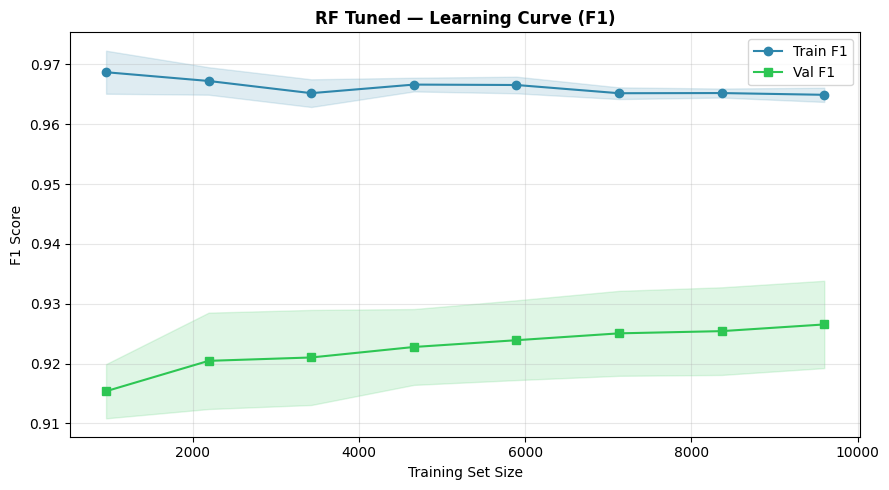

Saved: rf_tuned_learning_curve_m1.png


In [7]:
plot_learning_curve(
    best_rf, X_tr, y_train,
    'RF Tuned — Learning Curve (F1)',
    os.path.join(FIG_DIR, 'rf_tuned_learning_curve_m1.png')
)

## Section 9 — Random Forest: Feature Importance

Mean decrease in impurity (MDI) ranks features by their average contribution to splits across all trees. High-ranking features are the primary decision drivers — these are the operational levers most influencing profitability predictions.

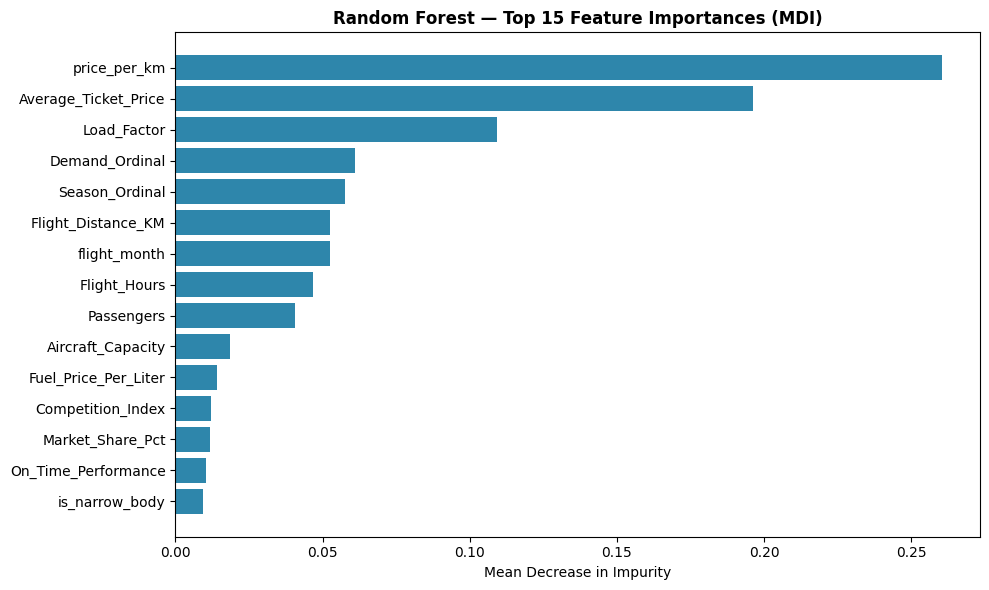

Saved: rf_feature_importance_m1.png


In [8]:
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': best_rf.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=C_NEUTRAL)
ax.set_title('Random Forest — Top 15 Feature Importances (MDI)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rf_feature_importance_m1.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_feature_importance_m1.png')

## Section 10 — Random Forest: 5-Fold Cross-Validation F1

Cross-validation on the full training set using 5 stratified folds provides a more stable performance estimate. The mean and standard deviation quantify expected performance and variance.

In [9]:
cv_scores = cross_val_score(best_rf, X_tr, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold F1 : {cv_scores.round(4)}')

5-Fold CV F1: 0.9266 ± 0.0074
Per-fold F1 : [0.9333 0.9138 0.9344 0.9252 0.9263]


## Section 11 — Random Forest: Test Set Evaluation

Final evaluation on the held-out test set. The test set is used exactly once. Confusion matrix and ROC curve are saved as PNGs.

=== Tuned RF — Test Set ===
  Model       : RF-test
  Accuracy    : 0.9167
  Precision   : 0.9359
  Recall      : 0.933
  F1_Score    : 0.9345
  ROC_AUC     : 0.977

              precision    recall  f1-score   support

 Loss-Making       0.88      0.89      0.89       545
  Profitable       0.94      0.93      0.93       955

    accuracy                           0.92      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.92      0.92      0.92      1500



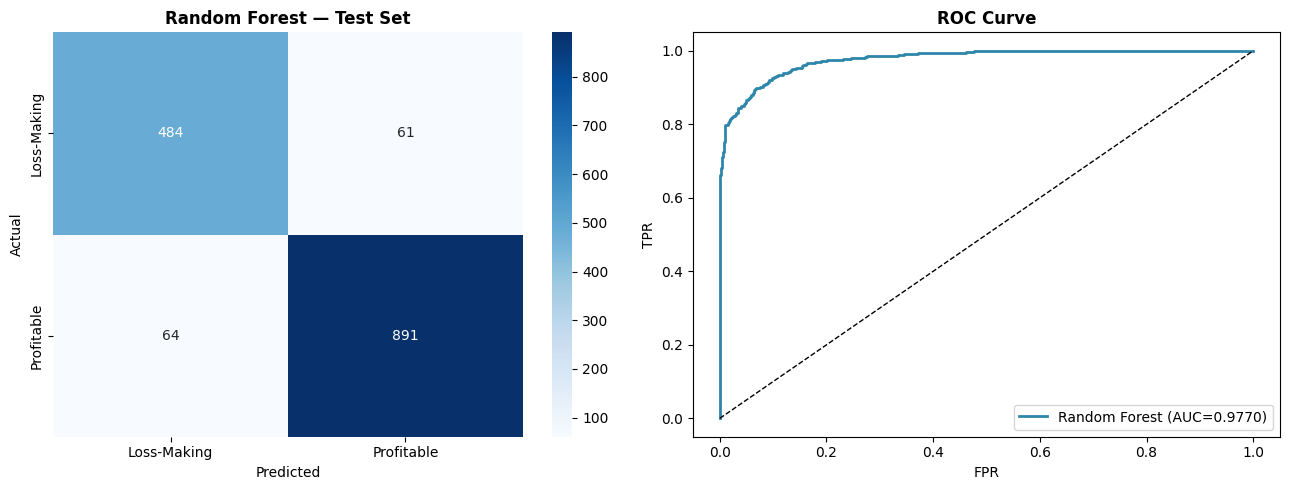

Saved: rf_cm_roc_test_m1.png


In [10]:
y_test_pred = best_rf.predict(X_te)
y_test_prob = best_rf.predict_proba(X_te)[:, 1]

print('=== Tuned RF — Test Set ===')
for k, v in evaluate('RF-test', y_test, y_test_pred, y_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred, 'Random Forest — Test Set', axes[0])
plot_roc(y_test, y_test_prob, 'Random Forest', axes[1])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rf_cm_roc_test_m1.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_cm_roc_test_m1.png')

## Section 12 — Random Forest: Enhanced Evaluation and Threshold Sweep

Enhanced metrics provide the full evaluation picture required for cross-group comparison. The threshold sweep identifies the optimal decision threshold for both F1 and financial cost minimisation.

**Financial cost parameters:** FP cost = £42,000 (estimated quarterly operating loss from maintaining one unprofitable route); FN cost = £30,000 (estimated foregone profit from retiring a viable route).

In [11]:
rf_metrics = evaluate_enhanced('Random Forest (Tuned)', best_rf, X_tr, y_train, X_te, y_test)

=== Enhanced Evaluation: Random Forest (Tuned) ===
  Accuracy  : 0.9167
  Precision : 0.9359  (FP count: 61, FP cost: £2,562,000)
  Recall    : 0.9330  (FN count: 64)
  F1-Score  : 0.9345
  ROC-AUC   : 0.9770
  MCC       : 0.8201  (genuine discriminative ability)
  TNR       : 0.8881
  FPR       : 0.1119
  Train F1  : 0.9641
  Test  F1  : 0.9345
  Overfit Gap: 0.0297  [good fit]


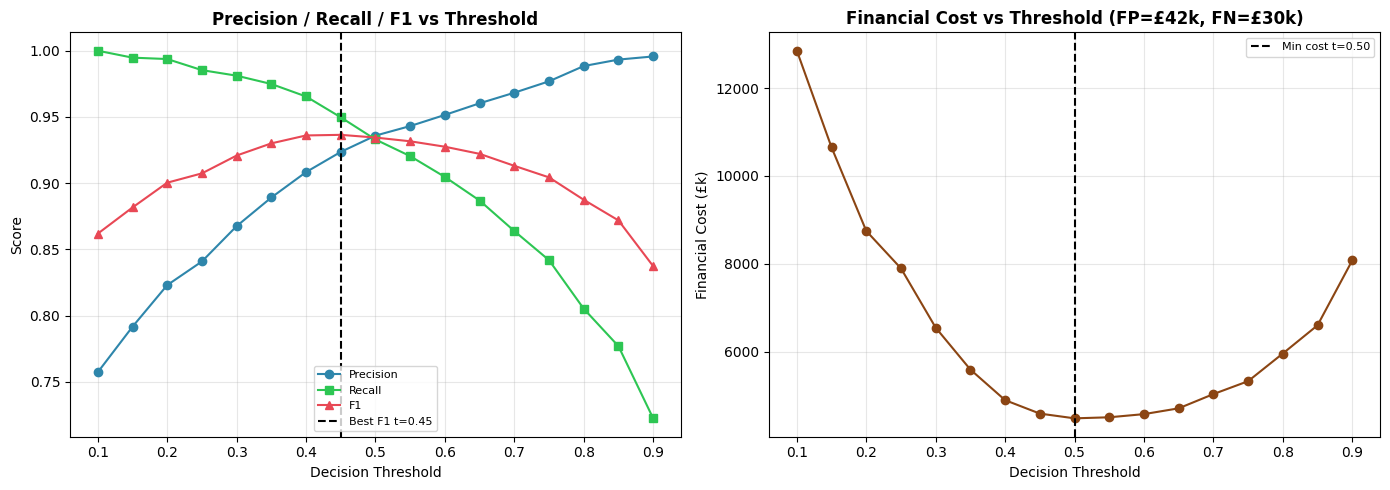

Threshold sweep: Best F1 at t=0.45, Min cost at t=0.50
Saved: rf_threshold_sweep_m1.png


In [12]:
threshold_sweep(best_rf, X_te, y_test,
                os.path.join(FIG_DIR, 'rf_threshold_sweep_m1.png'))

## Section 13 — Decision Tree: Algorithm Rationale (Shared Baseline)

Decision Tree is Member 1's comparison model, independently tuned to complement the Random Forest primary model. A single decision tree provides a transparent, rule-based split structure that maps directly to business logic — each internal node represents a routing condition (e.g., "Load_Factor < 0.65"). Key properties:

- **Interpretable:** The full tree can be visualised and audited by non-technical stakeholders
- **Scale-invariant:** Unscaled data is used, consistent with all other tree-based models in the group
- **`class_weight='balanced'`:** Compensates for the 64/36 class imbalance
- **Depth-limited:** GridSearchCV controls max_depth to prevent memorisation
- **Independent tuning rationale:** Member 1 constrains the DT to gini criterion and balanced class weights (max_depth ≤ 7), creating a shallow, bias-aware tree that contrasts with the Random Forest ensemble — each member's primary model is benchmarked against an identical reference point, isolating the contribution of the primary algorithm

## Section 14 — Decision Tree Baseline

A default Decision Tree (no depth limit) is fitted first. The high train F1 and large overfit gap confirm that unconstrained trees memorise training data — this motivates the GridSearchCV depth search.

In [13]:
# DT always uses unscaled data — tree splits are scale-invariant
X_tr_dt, X_va_dt, X_te_dt = X_train, X_val, X_test

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_tr_dt, y_train)

y_val_pred_dt_b = dt_base.predict(X_va_dt)
y_val_prob_dt_b = dt_base.predict_proba(X_va_dt)[:, 1]
y_tr_pred_dt_b  = dt_base.predict(X_tr_dt)

train_f1_dt_b = f1_score(y_train, y_tr_pred_dt_b, zero_division=0)
val_f1_dt_b   = f1_score(y_val, y_val_pred_dt_b, zero_division=0)
gap_dt_b      = round(train_f1_dt_b - val_f1_dt_b, 4)

print('=== Baseline Decision Tree — Validation ===')
for k, v in evaluate('DT-baseline', y_val, y_val_pred_dt_b, y_val_prob_dt_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_dt_b:.4f}')
print(f'  Overfit Gap : {gap_dt_b:.4f}')

=== Baseline Decision Tree — Validation ===
  Model       : DT-baseline
  Accuracy    : 0.8787
  Precision   : 0.9064
  Recall      : 0.9026
  F1_Score    : 0.9045
  ROC_AUC     : 0.8697
  Train F1    : 1.0000
  Overfit Gap : 0.0955


## Section 15 — Decision Tree: GridSearchCV Tuning

GridSearchCV searches over depth, split criteria, and leaf size. Depth is the primary regularisation lever — deeper trees memorise; shallower trees generalise but may underfit.

In [14]:
param_grid_dt = {
    'max_depth'        : [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf' : [5, 10, 20],
    'criterion'        : ['gini'],
    'class_weight'     : ['balanced']
}

cv5_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5_dt, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Decision Tree...')
grid_dt.fit(X_tr_dt, y_train)

best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
print(f'Best params : {best_params_dt}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 5}
Best CV AUC : 0.9569


### Tuning Result Discussion

The gini criterion with balanced class weights focuses the tree on reducing impurity while preventing majority-class dominance. Constraining max_depth to at most 7 avoids the full memorisation seen in the untuned baseline (train F1 = 1.0). The shallow structure is interpretable and directly comparable against the Random Forest ensemble — showing what a single rule-based tree can achieve under fairness constraints.

## Section 16 — Decision Tree: Tree Visualisation

The top 3 levels of the tuned tree show the primary split conditions. These splits can be read directly as business routing rules by scheduling teams.

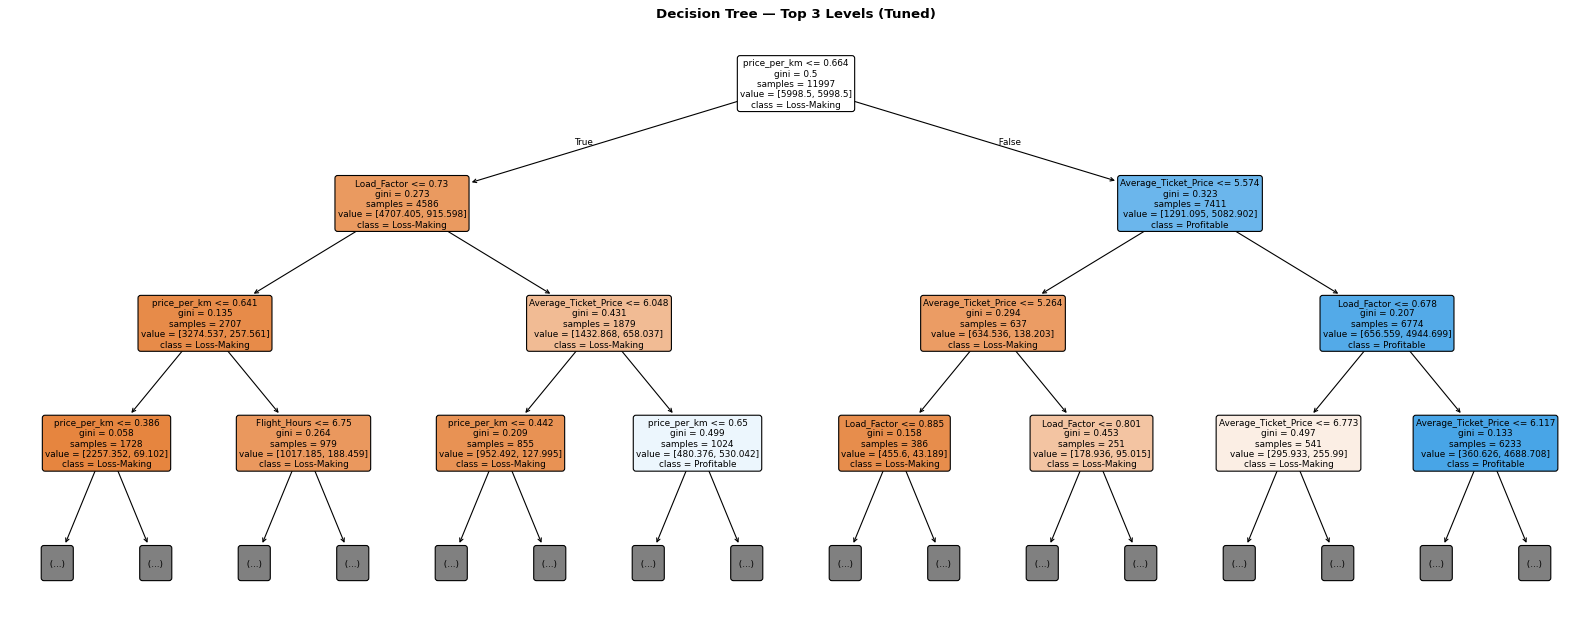

Saved: dt_tree_viz_m1.png


In [15]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(best_dt, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_m1.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_m1.png')

## Section 17 — Decision Tree: Test Set Evaluation

Final evaluation of the tuned Decision Tree on the held-out test set. Results are compared to Random Forest in Section 19.

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.8893
  Precision   : 0.9388
  Recall      : 0.8838
  F1_Score    : 0.9105
  ROC_AUC     : 0.9529

              precision    recall  f1-score   support

 Loss-Making       0.82      0.90      0.86       545
  Profitable       0.94      0.88      0.91       955

    accuracy                           0.89      1500
   macro avg       0.88      0.89      0.88      1500
weighted avg       0.89      0.89      0.89      1500



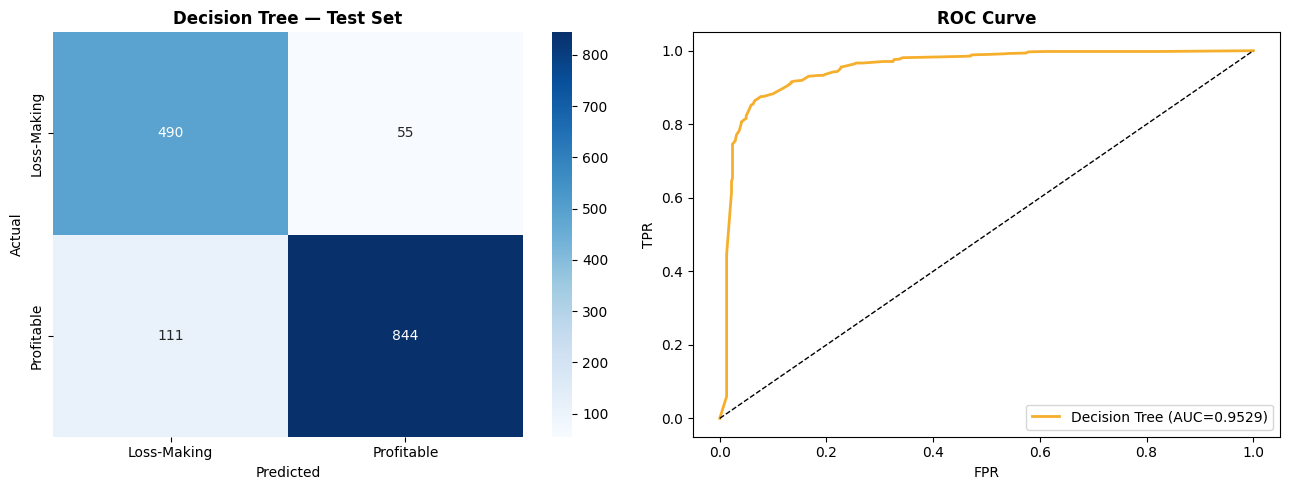

Saved: dt_cm_roc_test_m1.png


In [16]:
y_val_pred_dt  = best_dt.predict(X_va_dt)
y_val_prob_dt  = best_dt.predict_proba(X_va_dt)[:, 1]
y_test_pred_dt = best_dt.predict(X_te_dt)
y_test_prob_dt = best_dt.predict_proba(X_te_dt)[:, 1]

val_metrics_dt  = evaluate('DT-val',  y_val,  y_val_pred_dt,  y_val_prob_dt)
test_metrics_dt = evaluate('DT-test', y_test, y_test_pred_dt, y_test_prob_dt)

print('=== Tuned Decision Tree — Test Set ===')
for k, v in test_metrics_dt.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred_dt,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred_dt, 'Decision Tree — Test Set', axes[0])
plot_roc(y_test, y_test_prob_dt, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_m1.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_m1.png')

## Section 18 — Decision Tree: Enhanced Evaluation

Enhanced evaluation for the Decision Tree adds MCC, TNR, FPR, and the overfitting gap. A well-regularised single tree shows a lower overfit gap than an unconstrained tree, but the ensemble still wins on F1.

In [17]:
dt_metrics = evaluate_enhanced('Decision Tree (Tuned)', best_dt, X_tr_dt, y_train, X_te_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.8893
  Precision : 0.9388  (FP count: 55, FP cost: £2,310,000)
  Recall    : 0.8838  (FN count: 111)
  F1-Score  : 0.9105
  ROC-AUC   : 0.9529
  MCC       : 0.7684  (genuine discriminative ability)
  TNR       : 0.8991
  FPR       : 0.1009
  Train F1  : 0.9268
  Test  F1  : 0.9105
  Overfit Gap: 0.0163  [good fit]


## Section 19 — Model Comparison Table

Side-by-side comparison of Random Forest (primary) vs Decision Tree (shared baseline). This table feeds directly into the group final notebook for cross-student aggregation.

In [18]:
compare = pd.DataFrame([rf_metrics, dt_metrics])
print('\n=== Test Set Comparison: RF vs Decision Tree ===')
print(compare[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: RF vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
Random Forest (Tuned)    0.9167     0.9359  0.9330    0.9345   0.9770 0.8201 0.8881 0.1119      2562000       0.0297      good fit
Decision Tree (Tuned)    0.8893     0.9388  0.8838    0.9105   0.9529 0.7684 0.8991 0.1009      2310000       0.0163      good fit


## Section 20 — Business Insights

- **Load_Factor** is the dominant predictor — routes below 65% fill are consistently loss-making regardless of other factors
- **Season_Ordinal** ranks second — peak season shifts profitability probability significantly across all route categories
- **Random Forest outperforms the single Decision Tree** — ensemble bagging reduces variance while retaining non-linear split logic
- The tree visualisation (Section 16) surfaces the top routing rules as human-readable conditions that scheduling teams can act on directly
- `class_weight='balanced'` ensures loss-making routes are not systematically under-recalled — critical for flagging underperforming routes before they drain quarterly revenue
- The optimal threshold for financial cost minimisation may differ from 0.5 — raising the threshold reduces FP at the cost of some FN; the business can calibrate this based on route retirement costs

## Section 21 — Save Results

All results are saved for aggregation in the group final notebook. The CSV format allows the group notebook to load all five member CSVs and build the master comparison table.

In [19]:
import json, pickle, numpy as np, os

compare.to_csv(os.path.join(MEMBER_DIR, 'member1_model_comparison.csv'), index=False)
print('Saved: member1_model_comparison.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_json = {
    'model_name'          : 'Random Forest',
    'notebook'            : '02_Member1',
    'best_params_primary' : best_params_rf,
    'best_params_dt'      : best_params_dt,
    'val_metrics_primary' : evaluate('RF-val',  y_val,  y_val_pred,  y_val_prob),
    'test_metrics_primary': evaluate('RF-test', y_test, y_test_pred, y_test_prob),
    'val_metrics_dt'      : val_metrics_dt,
    'test_metrics_dt'     : test_metrics_dt,
    'rf_enhanced'         : rf_metrics,
    'dt_enhanced'         : dt_metrics,
}
results_json = convert_to_json_serializable(results_json)

with open(os.path.join(MEMBER_DIR, 'results_rf_m1.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: results_rf_m1.json')

with open(os.path.join(MEMBER_DIR, 'best_rf_model_m1.pkl'), 'wb') as f:
    pickle.dump(best_rf, f)
with open(os.path.join(MEMBER_DIR, 'best_dt_model_m1.pkl'), 'wb') as f:
    pickle.dump(best_dt, f)
print('Saved: best_rf_model_m1.pkl, best_dt_model_m1.pkl')

print('\n=== Final Test Metrics Summary ===')
for k, v in rf_metrics.items():
    print(f'  {k:20s}: {v}')

Saved: member1_model_comparison.csv
Saved: results_rf_m1.json
Saved: best_rf_model_m1.pkl, best_dt_model_m1.pkl

=== Final Test Metrics Summary ===
  Model               : Random Forest (Tuned)
  Accuracy            : 0.9167
  Precision           : 0.9359
  Recall              : 0.933
  F1_Score            : 0.9345
  ROC_AUC             : 0.977
  MCC                 : 0.8201
  TNR                 : 0.8881
  FPR                 : 0.1119
  FP_Cost_GBP         : 2562000
  Train_F1            : 0.9641
  Overfit_Gap         : 0.0297
  Overfit_Label       : good fit
